# Marchés statistiques : cartons, corners, tirs cadrés, buts… (cellules autonomes)
La première cellule charge les données et le style ; les suivantes sont la section 5 bis du notebook d'analyse.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib as mpl
BLUE, ORANGE, AQUA, YELLOW, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
mpl.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left", "lines.linewidth": 2,
    "legend.frameon": False, "figure.dpi": 110, "axes.axisbelow": True})
BIG = {"E0": "Premier League", "SP1": "Liga", "I1": "Serie A", "D1": "Bundesliga", "F1": "Ligue 1"}
URL = "https://raw.githubusercontent.com/xgabora/Club-Football-Match-Data-2000-2025/main/data/Matches.csv"
df = pd.read_csv(URL, parse_dates=["MatchDate"], low_memory=False)
df["Season"] = np.where(df.MatchDate.dt.month >= 7, df.MatchDate.dt.year, df.MatchDate.dt.year - 1)
B = df[df.Division.isin(BIG) & df.Season.between(2005, 2025)].copy()
B["Ligue"] = B.Division.map(BIG)
print(len(B), "matchs des 5 grands championnats, 2005/06 → 2025/26")

37642 matchs des 5 grands championnats, 2005/06 → 2025/26


## 5 bis. Tous les « marchés » statistiques : cartons, corners, tirs cadrés, buts…
Pour chaque statistique : moyenne par match (total, domicile, extérieur), distribution, fréquence de dépassement des lignes usuelles (« plus de X,5 ») et **cote juste** correspondante (= 1 / fréquence, sans marge).
Le dataset ne contient pas les cotes réelles des marchés cartons/corners/tirs : ces cotes justes servent de référence probabiliste, pas de prix de marché.

In [2]:
MARKETS = {  # nom : (colonne domicile, colonne extérieur, lignes usuelles)
    "Buts":               ("FTHome", "FTAway", [0.5, 1.5, 2.5, 3.5, 4.5]),
    "Buts 1re mi-temps":  ("HTHome", "HTAway", [0.5, 1.5, 2.5]),
    "Tirs cadrés":        ("HomeTarget", "AwayTarget", [6.5, 7.5, 8.5, 9.5, 10.5]),
    "Tirs":               ("HomeShots", "AwayShots", [20.5, 22.5, 24.5, 26.5, 28.5]),
    "Corners":            ("HomeCorners", "AwayCorners", [7.5, 8.5, 9.5, 10.5, 11.5]),
    "Cartons jaunes":     ("HomeYellow", "AwayYellow", [2.5, 3.5, 4.5, 5.5, 6.5]),
    "Cartons rouges":     ("HomeRed", "AwayRed", [0.5, 1.5]),
    "Fautes":             ("HomeFouls", "AwayFouls", [20.5, 22.5, 24.5, 26.5]),
}
MK = B.dropna(subset=[c for h, a, _ in MARKETS.values() for c in (h, a)]).copy()
for name, (h, a, _) in MARKETS.items():
    MK[name] = MK[h] + MK[a]
print(f"{len(MK):,} matchs des 5 grands championnats avec toutes les statistiques ({MK.Season.min()}/{MK.Season.min()+1-2000:02d} → {MK.Season.max()}/{MK.Season.max()+1-2000:02d})")

# Moyennes de l'ensemble
avg = pd.DataFrame({name: {"moyenne par match": MK[name].mean(), "domicile": MK[h].mean(), "extérieur": MK[a].mean(),
                           "médiane": MK[name].median(), "écart-type": MK[name].std(), "min": MK[name].min(), "max": MK[name].max()}
                    for name, (h, a, _) in MARKETS.items()}).T
display(avg.style.format("{:.2f}").format("{:.0f}", subset=["médiane", "min", "max"]))

36,556 matchs des 5 grands championnats avec toutes les statistiques (2005/06 → 2025/26)


,moyenne par match,domicile,extérieur,médiane,écart-type,min,max
Buts,2.72,1.54,1.19,3,1.67,0,12
Buts 1re mi-temps,1.20,0.68,0.52,1,1.09,0,8
Tirs cadrés,9.29,5.16,4.13,9,3.57,0,33
Tirs,24.94,13.79,11.15,25,5.89,3,54
Corners,10.08,5.62,4.46,10,3.48,0,28
Cartons jaunes,4.03,1.87,2.15,4,2.12,0,15
Cartons rouges,0.22,0.10,0.12,0,0.50,0,5
Fautes,27.34,13.47,13.86,27,7.73,0,72


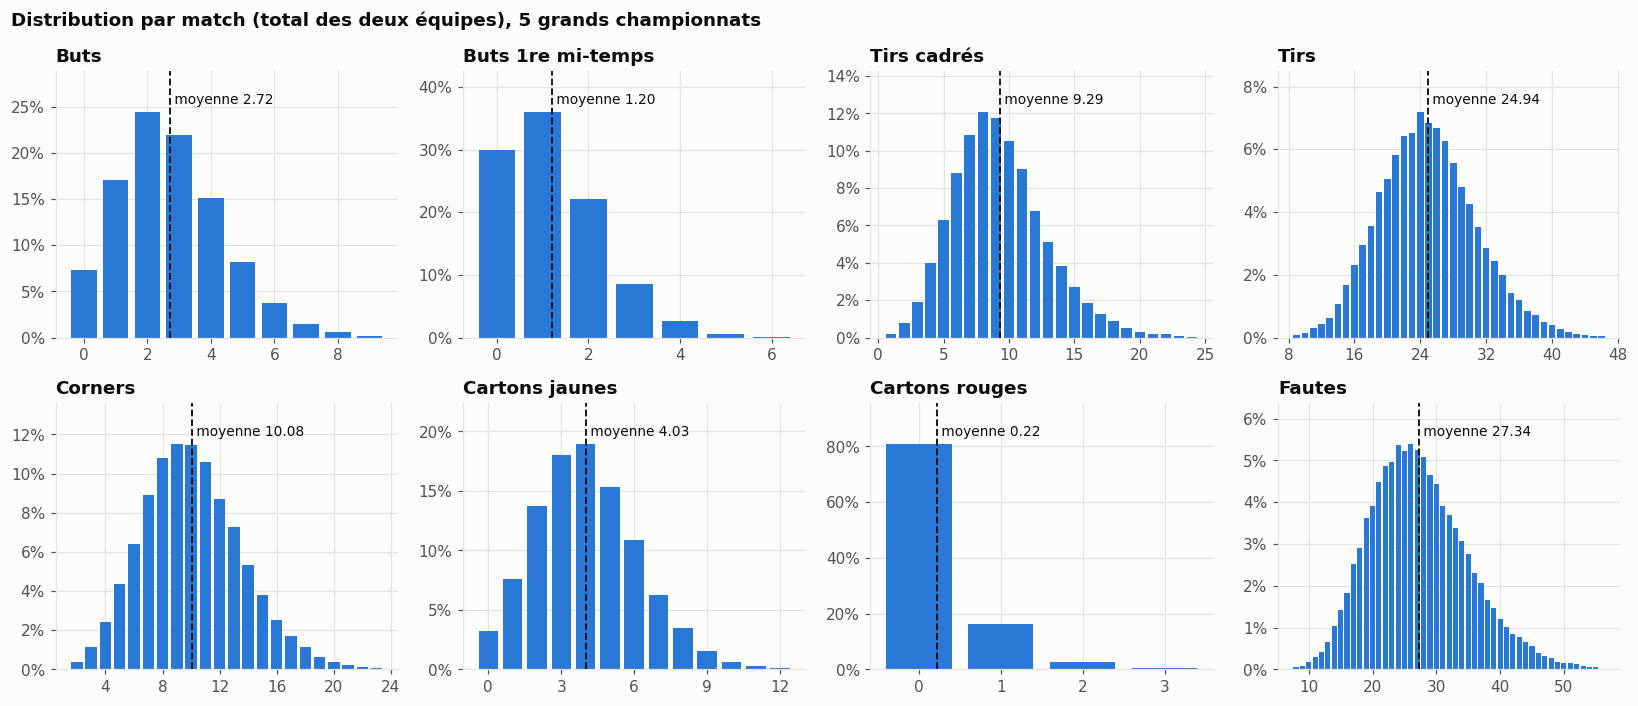

In [3]:
# Distributions : une petite figure par statistique, moyenne en pointillés
fig, axs = plt.subplots(2, 4, figsize=(15, 6.5))
for ax, name in zip(axs.ravel(), MARKETS):
    v = MK[name]; lo, hi = int(v.quantile(.001)), int(v.quantile(.999))
    freq = v.value_counts(normalize=True).sort_index().reindex(range(lo, hi + 1), fill_value=0)
    ax.bar(freq.index, freq.values, color=BLUE, width=0.8)
    ax.axvline(v.mean(), color=INK, ls="--", lw=1.2)
    ax.text(v.mean(), freq.max() * 1.02, f" moyenne {v.mean():.2f}", color=INK, fontsize=9, va="bottom")
    ax.set_title(name); ax.set_ylim(0, freq.max() * 1.18)
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1, decimals=0))
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True, nbins=6))
fig.suptitle("Distribution par match (total des deux équipes), 5 grands championnats", x=.01, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

In [4]:
# Fréquence des lignes « plus de X,5 » et cote juste équivalente
rows = []
for name, (h, a, lines) in MARKETS.items():
    for l in lines:
        p = (MK[name] > l).mean()
        rows.append({"marché": name, "ligne": f"plus de {l:g}", "fréquence": p, "cote juste « plus »": 1 / p if p > 0 else np.nan,
                     "cote juste « moins »": 1 / (1 - p) if p < 1 else np.nan})
lines_tab = pd.DataFrame(rows).set_index(["marché", "ligne"])
display(lines_tab.style.format({"fréquence": "{:.1%}", "cote juste « plus »": "{:.2f}", "cote juste « moins »": "{:.2f}"}))

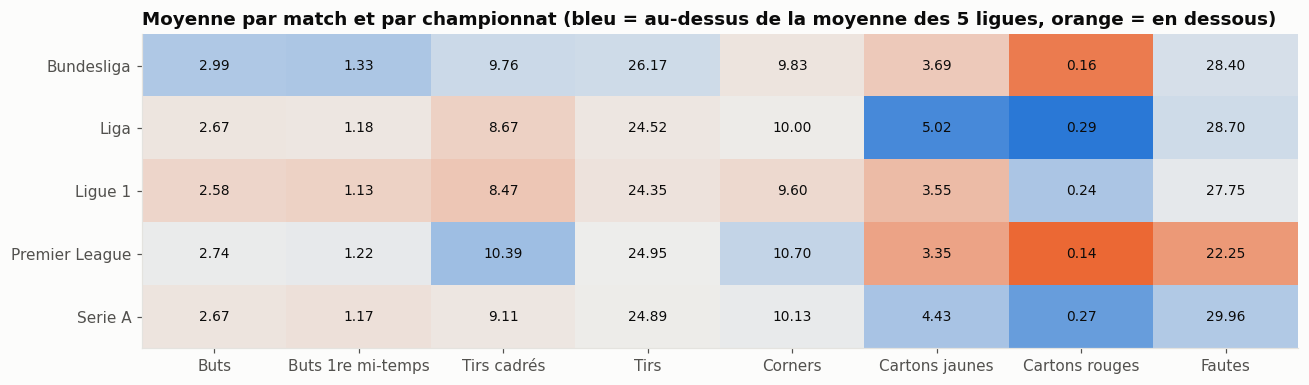

La Bundesliga a le plus de buts ; la Liga et la Serie A le plus de cartons ; la Premier League le plus de tirs cadrés et de corners mais le moins de fautes. Un modèle de marchés statistiques doit donc intégrer la ligue.


In [5]:
# Moyennes par championnat (heatmap normalisée par colonne : couleur = écart à la moyenne des 5 ligues)
by_lg = MK.groupby("Ligue")[list(MARKETS)].mean()
rel = by_lg / by_lg.mean() - 1
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.imshow(rel.values, cmap=mpl.colors.LinearSegmentedColormap.from_list("div", [ORANGE, "#eeeeec", BLUE]), vmin=-.3, vmax=.3, aspect="auto")
ax.grid(False); ax.set_xticks(range(rel.shape[1]), rel.columns); ax.set_yticks(range(rel.shape[0]), rel.index)
for i in range(rel.shape[0]):
    for j in range(rel.shape[1]):
        ax.text(j, i, f"{by_lg.values[i, j]:.2f}", ha="center", va="center", fontsize=9, color=INK)
ax.set_title("Moyenne par match et par championnat (bleu = au-dessus de la moyenne des 5 ligues, orange = en dessous)")
plt.tight_layout(); plt.show()
print("La Bundesliga a le plus de buts ; la Liga et la Serie A le plus de cartons ; la Premier League le plus de tirs cadrés et de corners mais le moins de fautes."
      " Un modèle de marchés statistiques doit donc intégrer la ligue.")

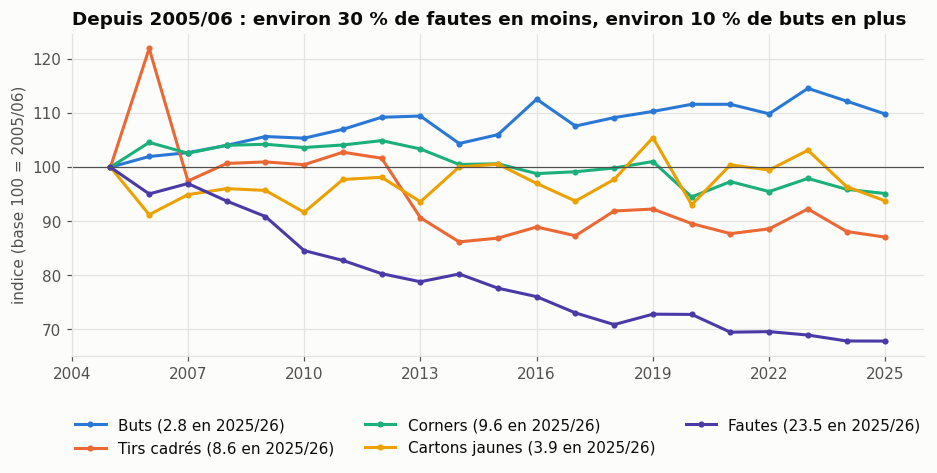

Le pic des tirs cadrés en 2006/07 ressemble à un changement de méthode de comptage de la source : à garder en tête avant d'utiliser cette variable sur des saisons anciennes.


In [6]:
# Évolution des moyennes dans le temps (indice base 100 = première saison disponible)
trend = MK.groupby("Season")[["Buts", "Tirs cadrés", "Corners", "Cartons jaunes", "Fautes"]].mean()
idx = trend / trend.iloc[0] * 100
fig, ax = plt.subplots(figsize=(10, 3.8))
for (col, c) in zip(idx.columns, [BLUE, ORANGE, AQUA, YELLOW, VIOLET]):
    ax.plot(idx.index, idx[col], marker="o", ms=3, color=c, label=f"{col} ({trend[col].iloc[-1]:.1f} en {trend.index[-1]}/{trend.index[-1]+1-2000:02d})")
ax.axhline(100, color=INK2, lw=.8); ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
ax.set_ylabel(f"indice (base 100 = {trend.index[0]}/{trend.index[0]+1-2000:02d})")
ax.set_title("Depuis 2005/06 : environ 30 % de fautes en moins, environ 10 % de buts en plus")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(.5, -.15)); plt.show()
print("Le pic des tirs cadrés en 2006/07 ressemble à un changement de méthode de comptage de la source : à garder en tête avant d'utiliser cette variable sur des saisons anciennes.")